In [150]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')

In [151]:
Bk_data = pd.read_csv('../Data/bank-full.csv')



In [152]:
Bk_data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [153]:
Bk_data.head(30)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [154]:
# jst making my own personal report :-
# job can be relataed to the outcome 
# maritail one might have a little connection with the out come because the married one can be more responsible 
# education wont have much of a coorelation
# i dont have any idea reagraing defalt i dont thinnk there will be any much of a cooreraltion
# yearly balance can have coorelationn ppl with good balance would like to invest 
# ppl with the housing loan usualy invest in such scheme because they cant stop investing there money for 10-15 year as the home loan periods are long ( but there is an catch as we see the data the ppl with theb home loan are not taking the scheme its liitle opposite )
# on the other hand the ppl with personal lona tends to pay of there pl first cause they are high intrest rated 
# well ignore day and month for a little as we are intrested in duration as the if we look from the sales aspect the call duartion is very much important the longer the duration there is a longer possiblity to close the cutomer ( and yes it is refelecting  in the data  ) but the catch over here is we need to predict for the data if they are going to buy or not so how can we predict the time they will spend on call so this col is not worth using , but yess if we are the calling the same old customer again then we can use it as the long time show case that ehy have or might shown some intrest in the prior call so we can reach them out again we might close them this time 
# previous is the number of time they got contacted not this can be little cofussing the more f/us we do the more chance are to get clossed but if the pt is notintreted then it can irritated them  but sitl more is better 
# the lesser and modrate the pdays the better it is 
# ppl who took the term deposit in the previous year are more likeyly to take this year too .


# my personal research in this genre :- 
# by the customer point of view who might be intrested in this kind of schemes are ppl who want to make money with out any risk 
# ppl who have stable and enough saving who dont need liquid instant widrawals can be likely to invest in this term
# the ppl who have recieved the bonusn or inhearited some good money would like to do that . 
#

In [155]:
Bk_data.tail(30)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
45181,46,blue-collar,married,secondary,no,6879,no,no,cellular,15,nov,74,2,118,3,failure,no
45182,34,technician,married,secondary,no,133,no,no,cellular,15,nov,401,2,187,5,success,yes
45183,70,retired,married,primary,no,324,no,no,cellular,15,nov,78,1,96,7,success,no
45184,63,retired,married,secondary,no,1495,no,no,cellular,16,nov,138,1,22,5,success,no
45185,60,services,married,tertiary,no,4256,yes,no,cellular,16,nov,200,1,92,4,success,yes
45186,59,unknown,married,unknown,no,1500,no,no,cellular,16,nov,280,1,104,2,failure,no
45187,32,services,single,secondary,no,1168,yes,no,cellular,16,nov,411,1,-1,0,unknown,yes
45188,29,management,single,secondary,no,703,yes,no,cellular,16,nov,236,1,550,2,success,yes
45189,25,services,single,secondary,no,199,no,no,cellular,16,nov,173,1,92,5,failure,no
45190,32,blue-collar,married,secondary,no,136,no,no,cellular,16,nov,206,1,188,3,success,yes


In [156]:
# EDA 

Bk_data.shape
# .17 col and 45k row

(45211, 17)

In [157]:
Bk_data.info()
# so in this data there is no null

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  Target     45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [158]:
Bk_data.describe()

# if we talk about the age younger the genration the faster money they wanna make the older the ppl the sttable the investment and returns thy wanna get so i think max older ppl weill take loan more 

# 50% of ppl have min balace of 450 so tbey not most likely ton invest brecause they might be hand to mouth but 75# of ppl have 1.4k+ so i thik mak ppl would love forward to invest
#  avg time spend on phone is 4min the ppl who are less tgen 100sec then they are not intrested and avg ppl 25% have 2min 510% 3 min maz ppl have 6 min call whihc is impresive they are most liky to get closed 
# in all of this i can do see the outlierd big ones 

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [159]:
Bk_data.describe(include="all")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [160]:
Bk_data.duplicated().sum()

np.int64(0)

In [161]:
Bk_data[Bk_data['Target'] == 'yes'].value_counts()

# 5289 ppl have said yes out of 45k

age  job         marital   education  default  balance  housing  loan  contact   day  month  duration  campaign  pdays  previous  poutcome  Target
59   admin.      married   secondary  no       2343     yes      no    unknown   5    may    1042      1         -1     0         unknown   yes       1
56   admin.      married   secondary  no       45       no       no    unknown   5    may    1467      1         -1     0         unknown   yes       1
41   technician  married   secondary  no       1270     yes      no    unknown   5    may    1389      1         -1     0         unknown   yes       1
55   services    married   secondary  no       2476     yes      no    unknown   5    may    579       1         -1     0         unknown   yes       1
54   admin.      married   tertiary   no       184      no       no    unknown   5    may    673       2         -1     0         unknown   yes       1
                                                                                             

In [162]:
# Business knowledge vs the Data know ledge 

# hese are NOT the same.

# Business team says

# Older people invest.

# Data might say

# 35-year-olds invest the most.

# Who's correct?

# The data.

# Business knowledge gives us hypotheses.

# Data confirms or rejects them.

In [163]:
(Bk_data["Target"].value_counts(normalize=True) * 100).round(2)

Target
no     88.3
yes    11.7
Name: proportion, dtype: float64

In [164]:
# Correlation ≠ Cause

# This sentence is one of the most famous in Data Science.

# Think about it.

# Did

# Long duration

# CAUSE

# the customer to buy?

# OR

# Did

# the interested customer

# naturally stay on the phone longer?

# Those are two completely different stories.

# Example

# Ice cream sales and drowning deaths both increase in summer.

# Does eating ice cream cause drowning?

# ❌ No.

# The hidden factor is hot weather.

# Likewise, longer calls don't magically convince people. More likely, interested people choose to stay on the call longer.

In [165]:
# KACHOW Principle #1

# Machine Learning doesn't create business value by making predictions.

# It creates value by helping businesses make better decisions.

# Prediction is just the tool.

# Decision-making is the goal.

In [166]:
Bk_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Target'],
      dtype='str')

In [167]:
print(Bk_data[['month','Target']].tail(50))


      month Target
45161   nov     no
45162   nov    yes
45163   nov     no
45164   nov     no
45165   nov     no
45166   nov    yes
45167   nov     no
45168   nov    yes
45169   nov     no
45170   nov     no
45171   nov     no
45172   nov     no
45173   nov     no
45174   nov    yes
45175   nov    yes
45176   nov    yes
45177   nov    yes
45178   nov    yes
45179   nov     no
45180   nov     no
45181   nov     no
45182   nov    yes
45183   nov     no
45184   nov     no
45185   nov    yes
45186   nov     no
45187   nov    yes
45188   nov    yes
45189   nov     no
45190   nov    yes
45191   nov    yes
45192   nov    yes
45193   nov    yes
45194   nov     no
45195   nov    yes
45196   nov    yes
45197   nov    yes
45198   nov     no
45199   nov     no
45200   nov    yes
45201   nov    yes
45202   nov    yes
45203   nov    yes
45204   nov    yes
45205   nov    yes
45206   nov    yes
45207   nov    yes
45208   nov    yes
45209   nov     no
45210   nov     no


In [168]:
print(Bk_data[['day','Target']].head(50))

    day Target
0     5     no
1     5     no
2     5     no
3     5     no
4     5     no
5     5     no
6     5     no
7     5     no
8     5     no
9     5     no
10    5     no
11    5     no
12    5     no
13    5     no
14    5     no
15    5     no
16    5     no
17    5     no
18    5     no
19    5     no
20    5     no
21    5     no
22    5     no
23    5     no
24    5     no
25    5     no
26    5     no
27    5     no
28    5     no
29    5     no
30    5     no
31    5     no
32    5     no
33    5     no
34    5     no
35    5     no
36    5     no
37    5     no
38    5     no
39    5     no
40    5     no
41    5     no
42    5     no
43    5     no
44    5     no
45    5     no
46    5     no
47    5     no
48    5     no
49    5     no


In [169]:
print(Bk_data[['day','Target']].tail(50))


       day Target
45161    9     no
45162    9    yes
45163    9     no
45164    9     no
45165    9     no
45166    9    yes
45167   10     no
45168   10    yes
45169   10     no
45170   10     no
45171   10     no
45172   10     no
45173   11     no
45174   11    yes
45175   11    yes
45176   11    yes
45177   12    yes
45178   12    yes
45179   12     no
45180   15     no
45181   15     no
45182   15    yes
45183   15     no
45184   16     no
45185   16    yes
45186   16     no
45187   16    yes
45188   16    yes
45189   16     no
45190   16    yes
45191   16    yes
45192   16    yes
45193   16    yes
45194   16     no
45195   16    yes
45196   16    yes
45197   16    yes
45198   16     no
45199   16     no
45200   16    yes
45201   17    yes
45202   17    yes
45203   17    yes
45204   17    yes
45205   17    yes
45206   17    yes
45207   17    yes
45208   17    yes
45209   17     no
45210   17     no


In [170]:
(Bk_data["month"].value_counts(normalize=True) * 100).round(2)


month
may    30.45
jul    15.25
aug    13.82
jun    11.81
nov     8.78
apr     6.49
feb     5.86
jan     3.10
oct     1.63
sep     1.28
mar     1.06
dec     0.47
Name: proportion, dtype: float64

In [171]:
# how many indivisual from each department invest 

Bk_data.groupby("job")["Target"].value_counts(normalize=True)

job            Target
admin.         no        0.877973
               yes       0.122027
blue-collar    no        0.927250
               yes       0.072750
entrepreneur   no        0.917283
               yes       0.082717
housemaid      no        0.912097
               yes       0.087903
management     no        0.862444
               yes       0.137556
retired        no        0.772085
               yes       0.227915
self-employed  no        0.881571
               yes       0.118429
services       no        0.911170
               yes       0.088830
student        no        0.713220
               yes       0.286780
technician     no        0.889430
               yes       0.110570
unemployed     no        0.844973
               yes       0.155027
unknown        no        0.881944
               yes       0.118056
Name: proportion, dtype: float64

In [172]:
# avg age group looks to in
Bk_data.groupby('Target')['age'].mean()


Target
no     40.838986
yes    41.670070
Name: age, dtype: float64

In [173]:
Bk_data.groupby('Target')['age'].median()


Target
no     39.0
yes    38.0
Name: age, dtype: float64

In [174]:
# what is the median balance thats ppl have who invest 

Bk_data.groupby("Target")["balance"].median()

Target
no     417.0
yes    733.0
Name: balance, dtype: float64

In [175]:
# it show the days when ppl have invested and have not 
pd.crosstab(Bk_data["day"], Bk_data["Target"], normalize="index")

Target,no,yes
day,,
1,0.720497,0.279503
2,0.859242,0.140758
3,0.835032,0.164968
4,0.840830,0.159170
5,0.887435,0.112565
6,0.906315,0.093685
7,0.913594,0.086406
8,0.890879,0.109121
9,0.885330,0.114670


In [176]:
# similar for the month as well

pd.crosstab(Bk_data["month"], Bk_data["Target"], normalize="index", )

Target,no,yes
month,,
apr,0.803206,0.196794
aug,0.889867,0.110133
dec,0.532710,0.467290
feb,0.833522,0.166478
jan,0.898788,0.101212
jul,0.909065,0.090935
jun,0.897772,0.102228
mar,0.480084,0.519916
may,0.932805,0.067195


In [177]:
# The Purpose of EDA

# EDA is NOT for pretty graphs.

# EDA has FOUR goals.

# Goal 1

# Find useful features.

# Keep them.

# Goal 2

# Find useless features.

# Remove them.

# Goal 3

# Find strange patterns.

# Investigate them.

# Goal 4

# Understand the business.

# That's it.

In [178]:
# 🎯 One last KACHOW Principle

# Write this in your notebook.

# EDA is not about understanding the dataset.

# EDA is about understanding the decisions you need to make before building the model.

In [179]:
# Can I know this feature BEFORE prediction?

# ↓

# YES → Keep

# NO → Remove

# ↓

# Will it help the model?

# ↓

# Does it need preprocessing?

# ↓

# Can the business actually provide this information?

Feature	Business Meaning	Available Before Prediction?	Leakage?	Encoding?	Scaling?	Decision

We'll fill it together.


In [180]:
# Business Meaning

# Customer's age.

# Available before prediction?

# ✅ Yes.

# The bank already knows it.

# Leakage?

# ❌ No.

# Encoding?

# ❌ No.

# It's already numeric.

# Scaling?

# ✅ Yes.

# Because KNN uses distance.

# Decision

# ✅ Keep

# this is the road map we can use to see that should we keep the feature or not 

In [181]:
# 1. What does this feature mean?

# ↓

# 2. Is it available before prediction?
# # 
# ↓

# 3. Does it leak future information?

# ↓

# 4. Does it make business sense?

# ↓

# 5. Is it numerical or categorical?

# ↓

# 6. Does it need encoding?

# ↓

# 7. Does it need scaling?

# ↓

# 8. Keep or remove?

In [182]:
# should we keep or should we not

# age - 
#     this shows the age of the customer
#     yes it avaibale
#     yes it does make a bussiness sence by some aspect 
#     no it do not leak any fuure info 
#     its a num
#     no 
#     i am not sure what scalling is 
#     we should keep the feature

# job - 
#     Keep 

# martial -
#     this is not the most imp feature i belive but yes can make a impact
#     keep

# education -
#     keep 

# contact -
#     when  we know the mode of contact is calling then it make no sence to keep it 
#     and it doest contribute in any prediction
# day - 


In [183]:
Bk_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Target'],
      dtype='str')

In [184]:
Bk_data[['balance']].head(10)

,balance
0,2143
1,29
2,2
3,1506
4,1
5,231
6,447
7,2
8,121
9,593


In [185]:
Bk_data.groupby('Target')['balance'].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
no,39922.0,1303.714969,2974.195473,-8019.0,58.0,417.0,1345.0,102127.0
yes,5289.0,1804.267915,3501.104777,-3058.0,210.0,733.0,2159.0,81204.0


In [186]:
# This is how every feature will be analyzed

# For every column, we'll follow this exact template:

# Step 1

# What is this feature?

# Example:

# balance = customer's account balance.

# Step 2

# Business Question

# Does balance influence subscription?

# Step 3

# Pandas Query

# Bk_data.groupby("Target")["balance"].describe()

# or

# Bk_data.groupby("Target")["balance"].median()
# Step 4

# Visualization

# (Boxplot, histogram, countplot, etc.)

# Step 5

# Conclusion

# Example:

# Customers who subscribed generally have higher balances, so balance appears to be a useful feature.

In [187]:
# note :- mean gets affect by outliers while medain ignores one 

# Large difference

# ↓

# Strong feature.

# Small difference

# ↓

# Maybe weak feature.

# Not always.

# But it's our first clue.

In [188]:
# EDA analysing all the features :- 

In [189]:
# age :  we have done the mean and median of the data 

# mean ppl invest in this are 41
# median is the 39



<Figure size 800x500 with 0 Axes>

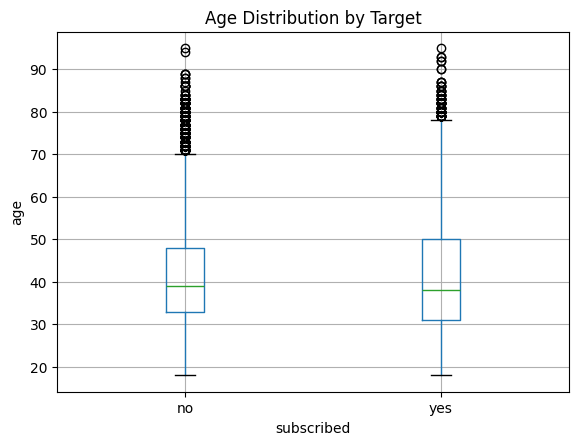

In [190]:
# visualizing 

plt.figure(figsize=(8,5))
Bk_data.boxplot(column='age', by='Target')

plt.title("Age Distribution by Target")
plt.suptitle('')
plt.xlabel('subscribed')
plt.ylabel('age')

plt.show()

In [191]:
# as we can see that there is a quite similarity btw the box plot and in both the sides have the equal the outliers we coult have consideres this feature to be an usefull or can say a greate feature if the boxes were to be in the diffrent position but both the boxes are in almost similar position even the median

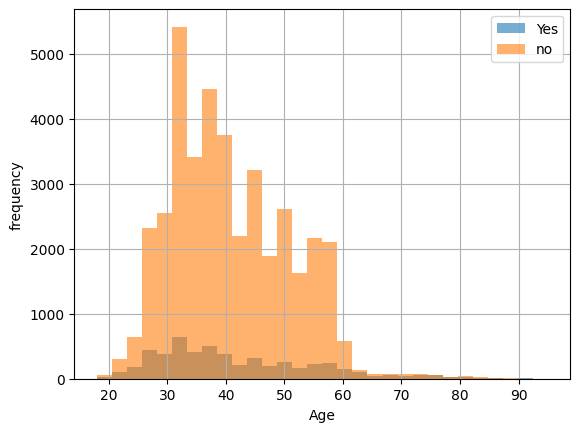

In [192]:
plt.Figure(figsize=(8,5))
Bk_data[Bk_data['Target'] == 'yes']['age'].hist(bins=30, alpha=0.6, label="Yes")
Bk_data[Bk_data['Target'] == 'no']['age'].hist(bins=30, alpha=0.6, label="no")

plt.xlabel('Age')
plt.ylabel('frequency')
plt.legend()

plt.show()



In [193]:
# i this distribution too we can find any major diffrent or any opposite distribution btw the yess or nos still we wont consider this age feature as an useless one we can use and see how does it work with the combined features 


In [194]:
Bk_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Target'],
      dtype='str')

In [195]:
# balance : - 

<Figure size 800x500 with 0 Axes>

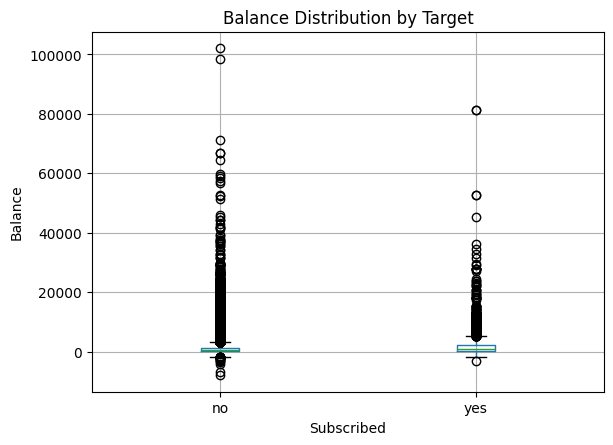

In [196]:
plt.figure(figsize=(8,5))
Bk_data.boxplot(column="balance", by="Target")

plt.title("Balance Distribution by Target")
plt.suptitle("")
plt.xlabel("Subscribed")
plt.ylabel("Balance")

plt.show()

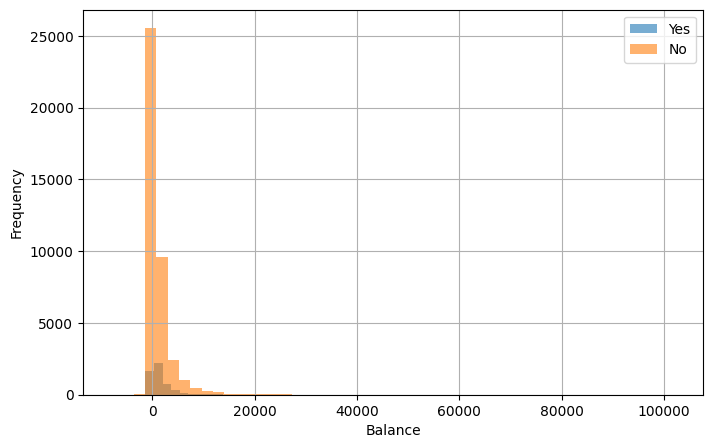

In [197]:
plt.figure(figsize=(8,5))

Bk_data[Bk_data["Target"]=="yes"]["balance"].hist(
    bins=50,
    alpha=0.6,
    label="Yes"
)

Bk_data[Bk_data["Target"]=="no"]["balance"].hist(
    bins=50,
    alpha=0.6,
    label="No",
    
)

plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [198]:
Bk_data["balance"].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

<Figure size 800x500 with 0 Axes>

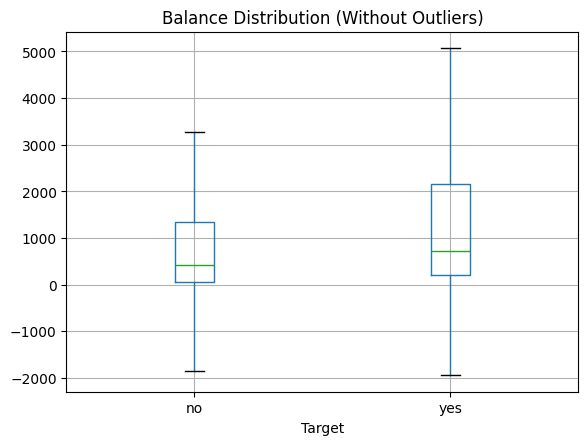

In [199]:
# we are unable to understand the graph so making some visiual changes 

plt.figure(figsize=(8,5))

Bk_data.boxplot(
    column="balance",
    by="Target",
    showfliers=False
)

plt.title("Balance Distribution (Without Outliers)")
plt.suptitle("")
plt.show()

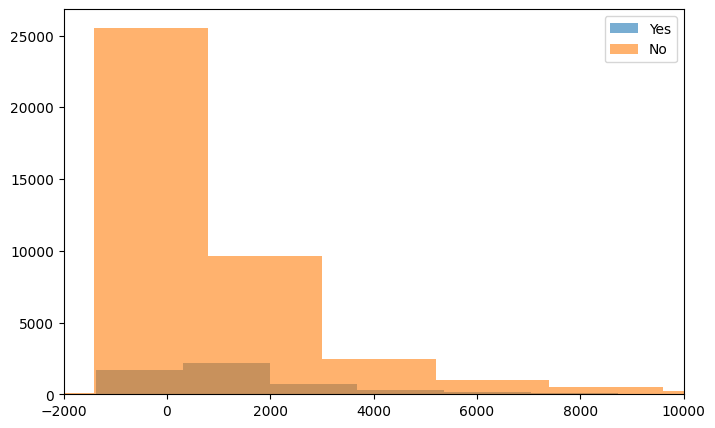

In [200]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    Bk_data[Bk_data["Target"]=="yes"]["balance"],
    bins=50,
    alpha=0.6,
    label="Yes"
)

plt.hist(
    Bk_data[Bk_data["Target"]=="no"]["balance"],
    bins=50,
    alpha=0.6,
    label="No"
)

plt.xlim(-2000, 10000)   # 👈 Zoom in

plt.legend()

plt.show()

In [201]:
# there is litte better distribution then age the box are at diffrent coordinates also median and this bar distribution so we can consider this as an better feature

In [202]:
# now we wont spend this time on all the feature we ll  move on with other feature quickly

In [203]:
Bk_data.groupby("Target")["day"].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
no,39922.0,15.892290,8.294728,1.0,8.0,16.0,21.0,31.0
yes,5289.0,15.158253,8.501875,1.0,8.0,15.0,22.0,31.0


In [204]:
# we have dropedx the duration feature due to the data leakage issue

Bk_data.groupby("Target")["duration"].describe()


,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
no,39922.0,221.182806,207.383237,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


In [205]:
Bk_data.groupby("Target")["campaign"].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
no,39922.0,2.846350,3.212767,1.0,1.0,2.0,3.0,63.0
yes,5289.0,2.141047,1.921826,1.0,1.0,2.0,3.0,32.0


In [206]:
Bk_data.groupby("Target")["pdays"].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
no,39922.0,36.421372,96.757135,-1.0,-1.0,-1.0,-1.0,871.0
yes,5289.0,68.702968,118.822266,-1.0,-1.0,-1.0,98.0,854.0


In [207]:
# now lets quickly wrap up the cat feature

In [208]:
Bk_data["job"].value_counts(normalize=True)
pd.crosstab(
    Bk_data["job"],
    Bk_data["Target"],
    normalize="index"
)

Target,no,yes
job,,
admin.,0.877973,0.122027
blue-collar,0.927250,0.072750
entrepreneur,0.917283,0.082717
housemaid,0.912097,0.087903
management,0.862444,0.137556
retired,0.772085,0.227915
self-employed,0.881571,0.118429
services,0.911170,0.088830
student,0.713220,0.286780


In [209]:

pd.crosstab(
    Bk_data["marital"],
    Bk_data["Target"],
    normalize="index"
)  

Target,no,yes
marital,,
divorced,0.880545,0.119455
married,0.898765,0.101235
single,0.850508,0.149492


In [210]:
pd.crosstab(
    Bk_data["education"],
    Bk_data["Target"],
    normalize="index"
)  

Target,no,yes
education,,
primary,0.913735,0.086265
secondary,0.894406,0.105594
tertiary,0.849936,0.150064
unknown,0.864297,0.135703


In [211]:
pd.crosstab(
    Bk_data["default"],
    Bk_data["Target"],
    normalize="index"
)  

Target,no,yes
default,,
no,0.882039,0.117961
yes,0.936196,0.063804


In [212]:
pd.crosstab(
    Bk_data["housing"],
    Bk_data["Target"],
    normalize="index"
)  

Target,no,yes
housing,,
no,0.832976,0.167024
yes,0.923000,0.077000


In [213]:
pd.crosstab(
    Bk_data["loan"],
    Bk_data["Target"],
    normalize="index"
)  

Target,no,yes
loan,,
no,0.873443,0.126557
yes,0.933186,0.066814


In [214]:
pd.crosstab(
    Bk_data["contact"],
    Bk_data["Target"],
    normalize="index"
)  

Target,no,yes
contact,,
cellular,0.850811,0.149189
telephone,0.865795,0.134205
unknown,0.959293,0.040707


In [215]:
pd.crosstab(
    Bk_data["month"],
    Bk_data["Target"],
    normalize="index"
)  

Target,no,yes
month,,
apr,0.803206,0.196794
aug,0.889867,0.110133
dec,0.532710,0.467290
feb,0.833522,0.166478
jan,0.898788,0.101212
jul,0.909065,0.090935
jun,0.897772,0.102228
mar,0.480084,0.519916
may,0.932805,0.067195


In [216]:
pd.crosstab(
    Bk_data["poutcome"],
    Bk_data["Target"],
    normalize="index"
)  

Target,no,yes
poutcome,,
failure,0.873903,0.126097
other,0.833152,0.166848
success,0.352747,0.647253
unknown,0.908385,0.091615


In [217]:
# Data Processing 

Bk_data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
Target       0
dtype: int64

In [218]:
# removing the data which is useless 

Bk_data = Bk_data.drop(columns=["duration"])

In [219]:
X = Bk_data.drop("Target", axis=1)

y = Bk_data["Target"]

In [220]:
# encoding 

In [221]:
categorical_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [222]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [223]:
Bk_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


In [224]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['no','yes']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [225]:
y_pred = knn.predict(X_test)

In [226]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.8780272033617162

Confusion Matrix
[[7818  167]
 [ 936  122]]

Classification Report
              precision    recall  f1-score   support

          no       0.89      0.98      0.93      7985
         yes       0.42      0.12      0.18      1058

    accuracy                           0.88      9043
   macro avg       0.66      0.55      0.56      9043
weighted avg       0.84      0.88      0.85      9043



In [227]:
from sklearn.metrics import roc_auc_score

y_prob = knn.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.6112166834553918


In [ ]:
# Although the model achieved an overall accuracy of 87.8%, it performed poorly on the minority class ("yes"), achieving a recall of only 12%. This indicates that the model failed to identify most potential subscribers, making it unsuitable for the bank's business objective.

In [229]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

train_acc = []
test_acc = []

neighbors = range(1, 31)

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc.append(
        accuracy_score(y_train, knn.predict(X_train))
    )

    test_acc.append(
        accuracy_score(y_test, knn.predict(X_test))
    )

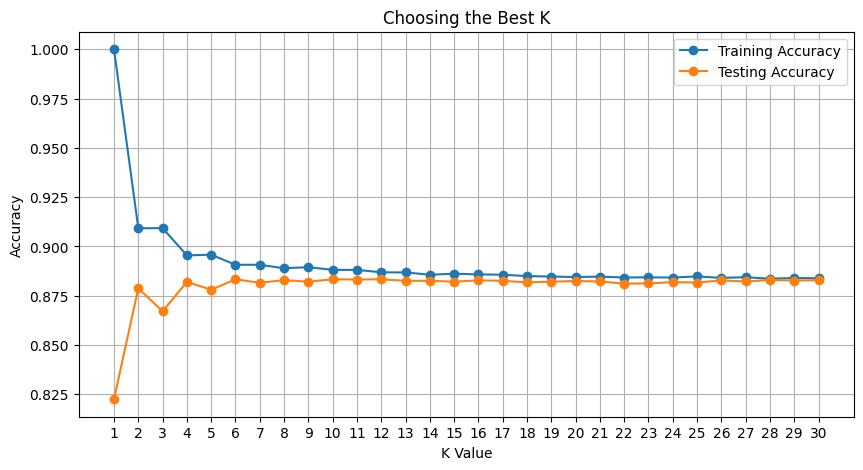

In [230]:
plt.figure(figsize=(10,5))

plt.plot(neighbors, train_acc, marker='o', label="Training Accuracy")
plt.plot(neighbors, test_acc, marker='o', label="Testing Accuracy")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Choosing the Best K")

plt.xticks(neighbors)
plt.grid(True)

plt.legend()

plt.show()

In [231]:

final_knn = KNeighborsClassifier(n_neighbors=6)

final_knn.fit(X_train, y_train)

y_pred = final_knn.predict(X_test)
y_prob = final_knn.predict_proba(X_test)[:, 1]

In [232]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8833351763795201

Confusion Matrix
[[7913   72]
 [ 983   75]]

Classification Report
              precision    recall  f1-score   support

          no       0.89      0.99      0.94      7985
         yes       0.51      0.07      0.12      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.53      0.53      9043
weighted avg       0.85      0.88      0.84      9043


ROC-AUC: 0.6150666478853901
